# Operational define of microbial maturity

## Results
- Separated by mmi-high, mmi-low group

# Protocol
- import to mmi file
- Based on the average MMI by age, healthy children are separated into mmi-high and mmi-low groups.
- Create and record network columns for future network analysis.
- Save results file
    - path: `data/mmi.tsv`



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.decomposition import PCA

## Microbiome age model results file import

In [ ]:
mmi = pd.read_csv("data/model.tsv", sep='\t').set_index('#SampleID')

In [8]:
mmi.head(-2)

,Unnamed: 0,real_age,mmi,real_year,pred_year,Months,host_sex,Host_disease,location_disease,mean_age,Separation,Network,Group
#SampleID,,,,,,,,,,,,,
SRR23478195,0,18.0,67.06,1.0,5.09,18.0,female,Control,Control(IT),50.83,mmihigh,mmihigh,mmihigh
SRR23478196,1,18.0,45.70,1.0,3.31,18.0,male,Control,Control(IT),50.83,mmilow,mmilow,mmilow
SRR23478197,2,18.0,39.73,1.0,2.81,18.0,female,Control,Control(IT),50.83,mmilow,mmilow,mmilow
SRR23478198,3,30.0,57.06,2.0,4.25,30.0,male,Control,Control(IT),56.42,mmihigh,mmihigh,mmihigh
SRR23478199,4,30.0,56.14,2.0,4.18,30.0,male,Control,Control(IT),56.42,mmilow,mmilow,mmilow
...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR23492550,136,90.0,95.87,7.0,7.49,90.0,NaN,PIBD,PIBD(IT),102.02,mmilow,PIBD,PIBD
SRR23492551,137,186.0,96.83,15.0,7.57,186.0,NaN,PIBD,PIBD(IT),122.46,mmilow,PIBD,PIBD
SRR23492553,138,186.0,69.30,15.0,5.28,186.0,NaN,PIBD,PIBD(IT),122.46,mmilow,PIBD,PIBD


In [ ]:
mmi["Network"].value_counts() ## Before applying quadratic based separation

Network
PIBD       49
mmihigh    47
mmilow     47
Name: count, dtype: int64

## Palette setting

In [10]:
palette = {                     # ver 1   # ver 2 # ver 3
    "mmihigh": "#326a81a0", #20854ea0 #326a81a0 #9fbcca
    "mmilow": "#9fbccaa0", #326a81a0 #9fbcca #a8ddb5
    "ulcerative colitis": "#fddbc7a0", #9fbcca #20854ea0 #ffeda0
    "crohn's disease": "#ef8a62", #7876b1c0 #7876b1c0 #feb24c
    "UC": "#7fcdbbc0",
    "CD": "#edf8b1c0",
    "MMI-high": "#326a81a0", #20854ea0 #326a81a0 #9fbcca
    "MMI-low": "#9fbccaa0", #326a81a0 #9fbcca #a8ddb5
    "PIBD": "#ef8a62"
}
plt.rcParams['font.size'] = 7
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
# affects whiskers, medians, caps (all Line2D)
plt.rcParams['lines.linewidth'] = 0.6


## Control MMI mean based separation (Not use)


### Only Control

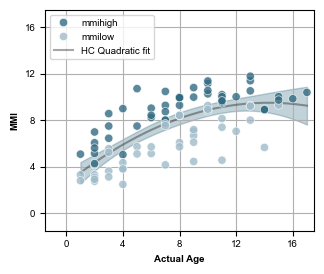

In [ ]:
hc = mmi[mmi['Host_disease'].str.contains('Control', case=False, na=False)].copy()




X = np.column_stack([hc['real_year']**2, hc['real_year']])
X = sm.add_constant(X)
model = sm.OLS(hc['pred_year'], X).fit()

# predict line + 95% CI
xg = np.linspace(hc['real_year'].min(), hc['real_year'].max(), 200)
Xg = sm.add_constant(np.column_stack([xg**2, xg]))
pred = model.get_prediction(Xg)
yfit = pred.predicted_mean
ci_low, ci_high = pred.conf_int().T



fig = plt.figure(figsize=(3.25,2.75))
ax = fig.add_subplot(111)
sns.scatterplot(data=mmi[mmi["Host_disease"] == "Control"], x='real_year', y='pred_year', hue='Separation', palette=palette, alpha=0.8, zorder=10)
#plt.plot([0,220], [0,200], '--', color='gray')

ax.plot(xg, yfit, color='black', lw=1.5, label='HC Quadratic fit', alpha=0.35)
ax.set_xlim(-1.5, 17.5)
ax.set_ylim(-1.5, 17.5)
ax.set_xticks(range(0,18,4))
ax.set_yticks(range(0,18,4))
ax.fill_between(xg, ci_low, ci_high, color='#326a81', alpha=0.3, linewidth=1)


ax.set_xlabel('Actual Age', fontweight='bold')
ax.set_ylabel('MMI', fontweight='bold')
ax.grid()
# affects whiskers, medians, caps (all Line2D)
ax.legend(loc='upper left')
fig.tight_layout()
#fig.savefig("figure/2_separation/mean_separation.pdf", dpi=300)


### All sample

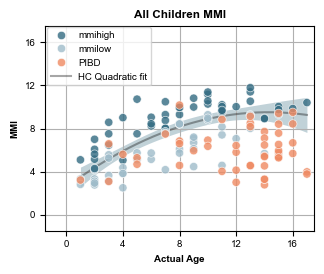

In [ ]:
hc = mmi[mmi['Host_disease'].str.contains('control', case=False, na=False)].copy()




X = np.column_stack([hc['real_year']**2, hc['real_year']])
X = sm.add_constant(X)
model = sm.OLS(hc['pred_year'], X).fit()

# predict line + 95% CI
xg = np.linspace(hc['real_year'].min(), hc['real_year'].max(), 200)
Xg = sm.add_constant(np.column_stack([xg**2, xg]))
pred = model.get_prediction(Xg)
yfit = pred.predicted_mean
ci_low, ci_high = pred.conf_int().T


fig = plt.figure(figsize=(3.25,2.75))
ax = fig.add_subplot(111)
sns.scatterplot(data=mmi, x='real_year', y='pred_year', hue='Network', palette=palette, alpha=0.8, zorder=10)
#plt.plot([0,200], [0,200], '--', color='gray')

ax.plot(xg, yfit, color='black', lw=1.5, label='HC Quadratic fit', alpha = 0.35)
ax.fill_between(xg, ci_low, ci_high, color='#326a81', alpha=0.3, linewidth=0)
ax.set_xlim(-1.5, 17.5)
ax.set_ylim(-1.5, 17.5)
ax.set_xticks(range(0,18,4))
ax.set_yticks(range(0,18,4))
ax.set_title('All Children MMI', fontweight='bold')
ax.set_xlabel('Actual Age', fontweight='bold')
ax.set_ylabel('MMI', fontweight='bold')
ax.grid()
ax.legend(loc='upper left', bbox_to_anchor=(-0.01, 1.02))
fig.tight_layout()
#fig.savefig("figure/2_separation/all_mean_separation.pdf", dpi=300, bbox_inches="tight")



## Quadratic fit line based separation (Use)

### Only control

mmibased
mmihigh    51
mmilow     43
Name: count, dtype: int64


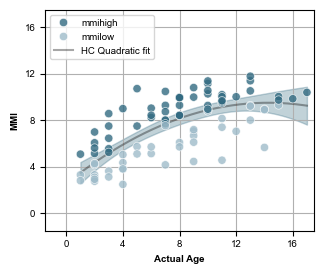

In [28]:

# HC only
hc_idx = mmi['Host_disease'].str.contains('Control', case=False, na=False)
hc = mmi.loc[hc_idx].copy()



# HC criteria quadratic model fitting
X = np.column_stack([hc['real_year']**2, hc['real_year']])
X = sm.add_constant(X)

model = sm.OLS(hc['pred_year'], X).fit()



# predict line + 95% CI
xg = np.linspace(hc['real_year'].min(), hc['real_year'].max(), 200)

Xg = np.column_stack([xg**2, xg])
Xg = sm.add_constant(Xg)

pred = model.get_prediction(Xg)
yfit = pred.predicted_mean
ci_low, ci_high = pred.conf_int().T


# fit, only hc
X_hc = np.column_stack([
    mmi.loc[hc_idx, 'real_year']**2,
    mmi.loc[hc_idx, 'real_year']
])
X_hc = sm.add_constant(X_hc)

mmi.loc[hc_idx, 'MMI_fit'] = model.predict(X_hc)


mmi.loc[hc_idx, 'mmibased'] = np.where(
    mmi.loc[hc_idx, 'pred_year'] >= mmi.loc[hc_idx, 'MMI_fit'],
    'mmihigh',
    'mmilow'
)

# Current group value uses, but HC sample do not use current group value 
mmi['mmibased'] = mmi['mmibased'].fillna(mmi['Group'])

print(mmi.loc[hc_idx, 'mmibased'].value_counts())





# plot

fig = plt.figure(figsize=(3.25, 2.75))
ax = fig.add_subplot(111)

sns.scatterplot(
    data=mmi.loc[hc_idx],
    x='real_year',
    y='pred_year',
    hue='mmibased',
    palette=palette,
    alpha=0.8,
    zorder=10,
    ax=ax
)

ax.plot(
    xg,
    yfit,
    color='black',
    lw=1.5,
    label='HC Quadratic fit',
    alpha=0.35
)

ax.fill_between(
    xg,
    ci_low,
    ci_high,
    color='#326a81',
    alpha=0.3,
    linewidth=1
)

ax.set_xlim(-1.5, 17.5)
ax.set_ylim(-1.5, 17.5)
ax.set_xticks(range(0, 18, 4))
ax.set_yticks(range(0, 18, 4))

ax.set_xlabel('Actual Age', fontweight='bold')
ax.set_ylabel('MMI', fontweight='bold')
ax.grid()

ax.legend(loc='upper left')

fig.tight_layout()
fig.savefig("figure/2_separation/linear_separation/linear_separation.pdf", dpi=300)

#### Save

In [30]:
mmi["mmibased"] = mmi["mmibased"].replace({
    "CD": "PIBD",
    "UC": "PIBD"
})

In [31]:
mmi.to_csv("data/mmi_fit_sepa.tsv", sep='\t')

### All samples

mmibased
mmihigh    51
PIBD       49
mmilow     43
Name: count, dtype: int64


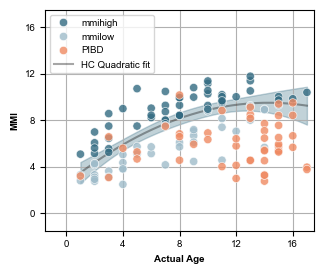

In [38]:
# HC only
hc_idx = mmi['Host_disease'].str.contains('Control', case=False, na=False)
hc = mmi.loc[hc_idx].copy()



# HC criteria quadratic model fitting
X = np.column_stack([hc['real_year']**2, hc['real_year']])
X = sm.add_constant(X)

model = sm.OLS(hc['pred_year'], X).fit()



# predict line + 95% CI
xg = np.linspace(hc['real_year'].min(), hc['real_year'].max(), 200)

Xg = np.column_stack([xg**2, xg])
Xg = sm.add_constant(Xg)

pred = model.get_prediction(Xg)
yfit = pred.predicted_mean
ci_low, ci_high = pred.conf_int().T


# fit, only hc
X_hc = np.column_stack([
    mmi.loc[hc_idx, 'real_year']**2,
    mmi.loc[hc_idx, 'real_year']
])
X_hc = sm.add_constant(X_hc)

mmi.loc[hc_idx, 'MMI_fit'] = model.predict(X_hc)


mmi.loc[hc_idx, 'mmibased'] = np.where(
    mmi.loc[hc_idx, 'pred_year'] >= mmi.loc[hc_idx, 'MMI_fit'],
    'mmihigh',
    'mmilow'
)

# Current group value uses, but HC sample do not use current group value 
mmi['mmibased'] = mmi['mmibased'].fillna(mmi['Group'])

print(mmi['mmibased'].value_counts())





# plot

fig = plt.figure(figsize=(3.25, 2.75))
ax = fig.add_subplot(111)

sns.scatterplot(
    data=mmi,
    x='real_year',
    y='pred_year',
    hue='mmibased',
    palette=palette,
    alpha=0.8,
    zorder=10,
    ax=ax
)

ax.plot(
    xg,
    yfit,
    color='black',
    lw=1.5,
    label='HC Quadratic fit',
    alpha=0.35
)

ax.fill_between(
    xg,
    ci_low,
    ci_high,
    color='#326a81',
    alpha=0.3,
    linewidth=1
)

ax.set_xlim(-1.5, 17.5)
ax.set_ylim(-1.5, 17.5)
ax.set_xticks(range(0, 18, 4))
ax.set_yticks(range(0, 18, 4))

ax.set_xlabel('Actual Age', fontweight='bold')
ax.set_ylabel('MMI', fontweight='bold')
ax.grid()

ax.legend(loc='upper left')

fig.tight_layout()
fig.savefig("figure/2_separation/linear_separation/all_linear_separation.pdf", dpi=300)